In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
NE_PSNR_Path = "./ne_lpn_results/NE_PSNRs.npy"
NE_SSIM_Path = "./ne_lpn_results/NE_SSIMs.npy"

In [3]:
sigma_noise = [0.02, 0.05, 0.1, 0.2, 0.3, 0.5]
sigma_noise = np.array(sigma_noise)
print(sigma_noise.shape)

(6,)


In [4]:
NE_PSNRs = np.load(NE_PSNR_Path)
NE_SSIMs = np.load(NE_SSIM_Path)

In [5]:
print(NE_PSNRs[:,0].shape)


(6,)


In [6]:
LPN_PSNR_Path = "./original_lpn_results/LPN_PSNRs.npy"
LPN_SSIM_Path = "./original_lpn_results/LPN_SSIMs.npy"

In [7]:
LPN_PSNRs = np.load(LPN_PSNR_Path)
LPN_SSIMs = np.load(LPN_SSIM_Path)

In [8]:
save_dir = "./test_result_figures/"
os.makedirs(save_dir, exist_ok=True)

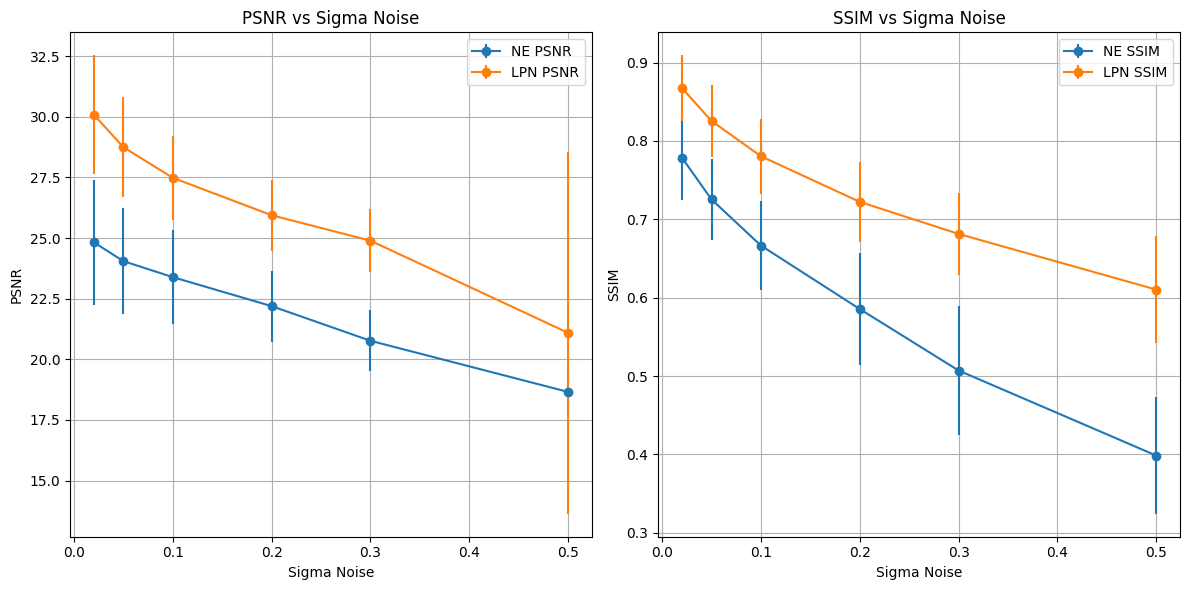

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].errorbar(sigma_noise, NE_PSNRs[:, 0], yerr=NE_PSNRs[:, 1], label='NE PSNR', fmt='-o')
ax[0].errorbar(sigma_noise, LPN_PSNRs[:, 0], yerr=LPN_PSNRs[:, 1], label='LPN PSNR', fmt='-o')
ax[0].set_xlabel('Sigma Noise')
ax[0].set_ylabel('PSNR')
ax[0].set_title('PSNR vs Sigma Noise')
ax[0].legend()
ax[0].grid(True)

# Plot SSIM vs sigma noise
ax[1].errorbar(sigma_noise, NE_SSIMs[:, 0], yerr=NE_SSIMs[:, 1], label='NE SSIM', fmt='-o')
ax[1].errorbar(sigma_noise, LPN_SSIMs[:, 0], yerr=LPN_SSIMs[:, 1], label='LPN SSIM', fmt='-o')
ax[1].set_xlabel('Sigma Noise')
ax[1].set_ylabel('SSIM')
ax[1].set_title('SSIM vs Sigma Noise')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()


In [10]:
save_path = os.path.join(save_dir, "NE_vs_LPN.png")
plt.savefig(save_path)
plt.close()